Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
ある素反応の速度定数が、別の素反応の速度定数の関数で表現される場合の事例  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。実験データには欠損を含んでもよい。  
2. RxnIVPsolv("sample_data.csv")でインスタンス化し、化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる。  
3. 作成した微分方程式を、数値解析可能な形式にする  
4.  scipy.optimize.minimizeを使い、化学種ごとの濃度の経時変化が、実験値と近づくように、未知の速度定数を求める： get_ode_system()で必要なオブジェクトを取得。  
5. 経時変化を図示する： matplotlibで結果をプロット  

もしエラーが発生した場合は、debug_ode_system()メソッドで詳細な情報を確認できる。  


## 引用文献  
2) 永井俊. 物理化学実験 「酢酸エステルの加水分解速度測定」 の問題点と改良法. 日本医科大学基礎科学紀要= The Bulletin of liberal arts & sciences, Nippon Medical School/日本医科大学基礎科学紀要編集委員会 編, 2015, 44: 1-24.  https://www.nms.ac.jp/library/college/pdf/kenkyujoho/katsudo/kiyou/no44/44thebulletin_takashi_nagai.pdf  

- 文献中2.2 疑二次法のデータ、Table 3, Table 4、および2.2.6記載の平衡定数を用いた。  
- 平衡反応で、何らかの方法で平衡定数が既知の状況を想定し、逆反応の速度定数は、正反応の速度定数に係数をかけて表現した。  


## 反応式を記載したcsvファイルを指定する  

In [1]:
file_path_rxn = './sample_data/ref2/sample_rxn_ref2b.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [3]:
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sympy import Symbol
from sympy.core.symbol import Symbol as SympySymbol
import inspect

from rxnfit.build_ode import RxnODEbuild, create_system_rhs
from rxnfit.solv_ode import SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read, get_y0_from_expdata
from rxnfit.expdata_fit_sci import ExpDataFitSci

# 反応速度式の作成

In [4]:
builded_rxnode = RxnODEbuild(file_path_rxn)

In [5]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 4
unique species: ['AcOEt', 'H2O', 'AcOH', 'EtOH']
rate constant: {'k1': k1, 'k2': 5.88235294117647*k1}

=== debug info ===
Successfully created function for AcOEt with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for H2O with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for AcOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for EtOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
order of args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
system of ODE: {'AcOEt': '-1/1*k1*AcOEt(t)*H2O(t)+1/1*k2*AcOH(t)*EtOH(t)', 'H2O': '-1/1*k1*AcOEt(t)*H2O(t)+1/1*k2*AcOH(t)*EtOH(t)', 'AcOH': '1/1*k1*AcOEt(t)*H2O(t)-1/1*k2*AcOH(t)*EtOH(t)', 'EtOH': '1/1*k1*AcOEt(t)*H2O(t)-1/1*k2*AcOH(t)*EtOH(t)'}


In [6]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

Successfully created function for AcOEt with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for H2O with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for AcOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for EtOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']


[Eq(Derivative(AcOEt(t), t), -k1*AcOEt(t)*H2O(t) + 5.88235294117647*k1*AcOH(t)*EtOH(t)),
 Eq(Derivative(H2O(t), t), -k1*AcOEt(t)*H2O(t) + 5.88235294117647*k1*AcOH(t)*EtOH(t)),
 Eq(Derivative(AcOH(t), t), k1*AcOEt(t)*H2O(t) - 5.88235294117647*k1*AcOH(t)*EtOH(t)),
 Eq(Derivative(EtOH(t), t), k1*AcOEt(t)*H2O(t) - 5.88235294117647*k1*AcOH(t)*EtOH(t))]

In [7]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

{'k1': k1, 'k2': 5.88235294117647*k1}


[sympy.core.symbol.Symbol, sympy.core.mul.Mul]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [8]:
file_path_data = './sample_data/ref2/sample_timecourse_ref2.csv' # データファイルのパス
df1 = pd.read_csv(file_path_data)

expdata_read([df1,])  # 複数データフレームのリストを渡すとまとめて読み込み可能

[([array([   0.  ,    5.13,   12.95,   18.15,   29.08,   40.18,   51.15,
            61.7 ,   74.75,   91.33,  106.58,  127.57,  147.88,  181.  ,
           210.7 ,  240.85,  300.72,  367.65,  420.97,  486.52,  555.48,
          1569.3 , 1712.15]),
   array([   0.  ,    5.13,   12.95,   18.15,   29.08,   40.18,   51.15,
            61.7 ,   74.75,   91.33,  106.58,  127.57,  147.88,  181.  ,
           210.7 ,  240.85,  300.72,  367.65,  420.97,  486.52,  555.48,
          1569.3 , 1712.15]),
   array([   0.  ,    5.13,   12.95,   18.15,   29.08,   40.18,   51.15,
            61.7 ,   74.75,   91.33,  106.58,  127.57,  147.88,  181.  ,
           210.7 ,  240.85,  300.72,  367.65,  420.97,  486.52,  555.48,
          1569.3 , 1712.15]),
   array([   0.  ,    5.13,   12.95,   18.15,   29.08,   40.18,   51.15,
            61.7 ,   74.75,   91.33,  106.58,  127.57,  147.88,  181.  ,
           210.7 ,  240.85,  300.72,  367.65,  420.97,  486.52,  555.48,
          1569.3 , 1712.15])],
  [

### フィッティング  
ExpDataFitSci でシンボリックな速度定数をフィッティング。  


In [9]:
# ExpDataFitSci でフィッティング（t_range, df_list 必須）
t_range = (float(df1.iloc[:, 0].min()), float(df1.iloc[:, 0].max()))
fit_sci = ExpDataFitSci(builded_rxnode, [df1], t_range)
result, param_info, fit_metrics = fit_sci.run_fit(p0={"k1": 0.0001})  # initial guess for symbolic rate constant(s)

Successfully created function for AcOEt with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for H2O with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for AcOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Successfully created function for EtOH with args: ['t', 'AcOEt', 'H2O', 'AcOH', 'EtOH']
Optimization success: True
Fitted rate constants:
  k1 = 0.000122239
Residual sum of squares: 0.0053795  R²: 0.998093



=== Time-course plot ===


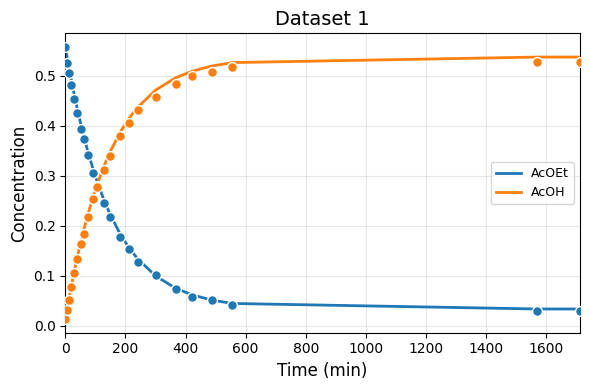


=== Concentration at the final time point ===
Dataset 1:
  AcOEt: 0.033262
  AcOH: 0.537538


In [10]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(expdata_df=df1, species=['AcOEt', 'AcOH'])